<a href="https://colab.research.google.com/github/Sneha8126/ML-Projects/blob/main/Mask%26WithoutMask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from zipfile import ZipFile
dataset = '/content/drive/MyDrive/Colab Notebooks/Toppers Acadmy Data/data/Machine Learning/Computer vision/archive.zip'


In [ ]:
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_files = os.listdir('/content/data/with_mask')
without_mask_files = os.listdir('/content/data/without_mask')

In [ ]:
with_mask_files[:5]

['with_mask_441.jpg',
 'with_mask_2285.jpg',
 'with_mask_1851.jpg',
 'with_mask_3717.jpg',
 'with_mask_1170.jpg']

In [ ]:
without_mask_files[:5]

['without_mask_172.jpg',
 'without_mask_1366.jpg',
 'without_mask_1258.jpg',
 'without_mask_848.jpg',
 'without_mask_450.jpg']

In [ ]:
print(len(with_mask_files))
print(len(without_mask_files))

3725
3828


with mask  -->  1

without mask  -->  0

In [ ]:
with_mask_labels = [1]*len(with_mask_files)
without_mask_labels = [0]*len(without_mask_files)

In [ ]:
with_mask_labels[:5]

[1, 1, 1, 1, 1]

In [ ]:
without_mask_labels[:5]

[0, 0, 0, 0, 0]

In [ ]:
labels = with_mask_labels+without_mask_labels
print(len(labels))

7553


**Displaying the Images**

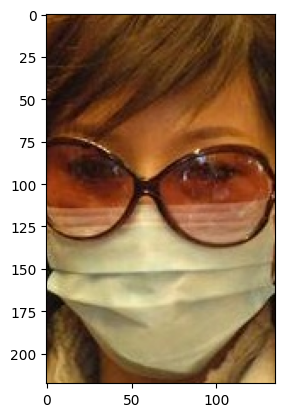

In [ ]:
img = mpimg.imread('/content/data/with_mask/with_mask_10.jpg')
imgplot = plt.imshow(img)
plt.show()

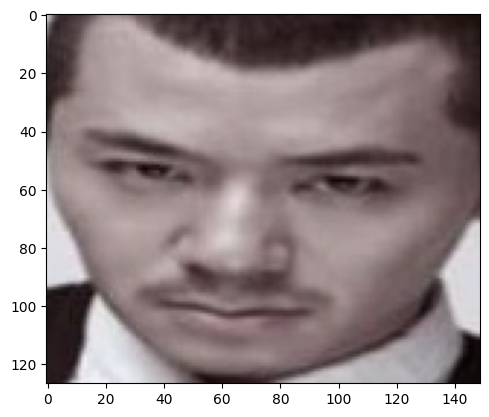

In [ ]:
img = mpimg.imread('/content/data/without_mask/without_mask_100.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [ ]:
with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:
  image = Image.open(with_mask_path+img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)


without_mask_path = '/content/data/without_mask/'

for img_file in without_mask_files:
  image = Image.open(without_mask_path+img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


array([[[ 60, 117, 112],
        [102, 155, 151],
        [ 90, 134, 133],
        ...,
        [ 37,  79,  75],
        [ 46,  90,  85],
        [ 49,  95,  90]],

       [[ 95, 145, 142],
        [113, 158, 157],
        [ 73, 109, 111],
        ...,
        [ 37,  72,  70],
        [ 42,  78,  76],
        [ 45,  83,  81]],

       [[ 73, 114, 113],
        [ 71, 106, 107],
        [ 63,  88,  92],
        ...,
        [ 35,  60,  61],
        [ 37,  65,  65],
        [ 39,  70,  69]],

       ...,

       [[ 63,  47,  54],
        [ 66,  50,  60],
        [ 70,  55,  65],
        ...,
        [ 70,  83,  98],
        [128, 152, 174],
        [150, 180, 210]],

       [[ 67,  49,  57],
        [ 67,  51,  60],
        [ 70,  52,  64],
        ...,
        [ 21,  23,  29],
        [ 43,  52,  63],
        [ 95, 107, 126]],

       [[ 75,  56,  64],
        [ 76,  59,  68],
        [ 79,  61,  74],
        ...,
        [ 20,  15,  21],
        [ 16,  13,  21],
        [ 22,  21,  32]]], dtype=uint8)
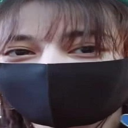

In [ ]:
data[0]

array([[[ 49, 228, 198],
        [ 41, 224, 194],
        [ 27, 219, 191],
        ...,
        [102, 251, 237],
        [110, 252, 240],
        [119, 255, 244]],

       [[ 38, 226, 195],
        [ 33, 225, 195],
        [ 21, 221, 192],
        ...,
        [ 99, 248, 234],
        [104, 246, 232],
        [106, 247, 234]],

       [[ 20, 227, 194],
        [ 17, 227, 195],
        [ 13, 224, 193],
        ...,
        [104, 251, 235],
        [104, 250, 234],
        [100, 246, 229]],

       ...,

       [[  9,  47, 135],
        [ 10,  46, 131],
        [ 16,  47, 128],
        ...,
        [ 18,  72, 163],
        [ 30,  85, 176],
        [ 34,  91, 181]],

       [[ 13,  50, 139],
        [ 12,  48, 134],
        [ 17,  47, 129],
        ...,
        [ 18,  73, 164],
        [ 31,  86, 177],
        [ 36,  93, 183]],

       [[ 15,  52, 141],
        [ 13,  49, 134],
        [ 16,  46, 128],
        ...,
        [ 18,  73, 164],
        [ 31,  86, 179],
        [ 36,  92, 185]]], dtype=uint8)
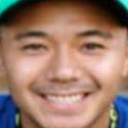

In [ ]:
data[7000]

In [ ]:
x = np.array(data)
y = np.array(labels)

**Train Test Split**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [ ]:
x_train[0].max()

np.uint8(255)

In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
x_train[0]

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

**Building a Convolutional Neural Networks (CNN)**

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
num_of_classes = 2

model = keras.Sequential()

# kernel_size=(3, 3): Size of the convolution kernel.
# input_shape=(height, width, channels)
# MaxPooling2D - this layer is added after a convolutional layer to reduce the spatial dimensions of the feature maps
# -and control overfitting by reducing the number of parameters.
model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
# It's a common practice to use dropout after fully connected (dense) layers
# or sometimes after convolutional layers to improve generalization.
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


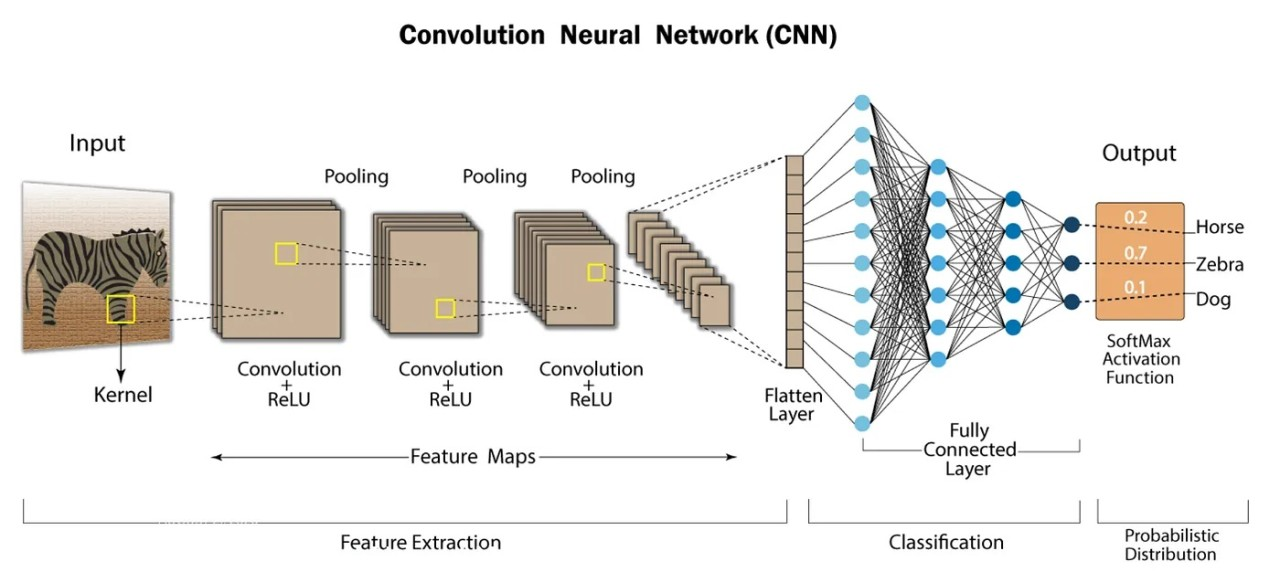

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,674,626 (6.39 MB)

 Trainable params: 1,674,626 (6.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [ ]:
model.fit(x_train, y_train, validation_split=0.1, epochs=50)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 150s 872ms/step - acc: 0.7979 - loss: 0.4592 - val_acc: 0.8860 - val_loss: 0.2819
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 154s 902ms/step - acc: 0.8762 - loss: 0.3013 - val_acc: 0.9091 - val_loss: 0.2326
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 194s 860ms/step - acc: 0.9053 - loss: 0.2454 - val_acc: 0.9157 - val_loss: 0.2119
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 148s 873ms/step - acc: 0.9126 - loss: 0.2162 - val_acc: 0.8926 - val_loss: 0.2513
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 205s 888ms/step - acc: 0.9272 - loss: 0.1889 - val_acc: 0.9306 - val_loss: 0.1961


In [ ]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [ ]:
train_pred[:5]

array([[0.06981952, 0.9533038 ],
       [0.48053265, 0.47300845],
       [0.02444344, 0.9693898 ],
       [0.66159374, 0.32386404],
       [0.9035719 , 0.05640533]], dtype=float32)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print(accuracy_score(y_train, np.argmax(train_pred, axis=1)))
print(accuracy_score(y_test, np.argmax(test_pred, axis=1)))

0.949685534591195
0.9338186631369954


In [ ]:
np.argmax(train_pred, axis=1)

array([1, 0, 1, ..., 0, 1, 0])

**Predictive System**

Path of the image to be predicted: /content/data/with_mask/with_mask_1333.jpg


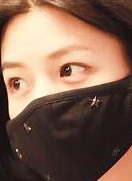

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.30552697 0.71993166]]
1
The person in the image is wearing a mask


In [ ]:


input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')